In [ ]:
!pip install kaggle
!kaggle datasets list | head
!export KAGGLE_API_TOKEN=KGAT_e0d4b880e92a4cb6dfff3ca75770a3d3

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'himajachaluvadi'
os.environ['KAGGLE_KEY'] = 'KGAT_e0d4b880e92a4cb6dfff3ca75770a3d3'
!kaggle datasets download -d dasa7753912/new-paddy-doctor-paddy-disease-classification

Dataset URL: https://www.kaggle.com/datasets/dasa7753912/new-paddy-doctor-paddy-disease-classification
License(s): unknown
 95% 2.07G/2.17G [00:22<00:02, 48.8MB/s]
100% 2.17G/2.17G [00:22<00:00, 103MB/s] 


In [ ]:
!unzip new-paddy-doctor-paddy-disease-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: paddy-disease-classification/train_images/hispa/104947.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104955.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104959.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104960.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104967.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104969.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104973.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104976.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104979.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104981.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104985.jpg  
  inflating: paddy-disease-classification/train_images/hispa/104986.jpg  
  inflating: paddy-disease-classification/train_images/hispa/

In [ ]:
import os

dataset_path = '/content/paddy-disease-classification/test_images'
classes = os.listdir(dataset_path)
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    image_count = len(os.listdir(class_path))
    print(f"{cls}: {image_count} images")

tungro: 1088 images
blast: 1738 images
downy_mildew: 620 images
bacterial_leaf_streak: 380 images
bacterial_panicle_blight: 337 images
bacterial_leaf_blight: 479 images
hispa: 1594 images
brown_spot: 965 images
normal: 1764 images
dead_heart: 1442 images


In [ ]:
import os

dataset_path = '/content/paddy-disease-classification/train_images'
classes = os.listdir(dataset_path)
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    image_count = len(os.listdir(class_path))
    print(f"{cls}: {image_count} images")

tungro: 1936 images
blast: 1918 images
downy_mildew: 1944 images
bacterial_leaf_streak: 1900 images
bacterial_panicle_blight: 1863 images
bacterial_leaf_blight: 1916 images
hispa: 1942 images
brown_spot: 1930 images
normal: 1872 images
dead_heart: 1910 images


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Define paths
train_path = '/content/paddy-disease-classification/train_images'
test_path = '/content/paddy-disease-classification/test_images'

In [ ]:
# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

In [ ]:
# Load data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 19131 images belonging to 10 classes.
Found 10407 images belonging to 10 classes.


In [ ]:
# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.5)(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Define model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Unfreeze last few layers for fine-tuning
for layer in base_model.layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True

# Recompile with lower learning rate
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Fine-tune
history_fine = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    class_weight=class_weight_dict,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 358s 544ms/step - accuracy: 0.3997 - loss: 7.5864 - val_accuracy: 0.6790 - val_loss: 3.7282
Epoch 2/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 285s 477ms/step - accuracy: 0.7081 - loss: 3.1326 - val_accuracy: 0.7703 - val_loss: 1.8237
Epoch 3/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 287s 480ms/step - accuracy: 0.7826 - loss: 1.6052 - val_accuracy: 0.8071 - val_loss: 1.1047
Epoch 4/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 292s 489ms/step - accuracy: 0.8276 - loss: 0.9880 - val_accuracy: 0.8395 - val_loss: 0.7890
Epoch 5/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 294s 492ms/step - accuracy: 0.8537 - loss: 0.7038 - val_accuracy: 0.8645 - val_loss: 0.6111
Epoch 6/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 290s 485ms/step - accuracy: 0.8702 - loss: 0.5668 - val_accuracy: 0.8715 - val_loss: 0.5194
Epoch 7/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 290s 484ms/step - accuracy: 0.8905 - loss: 0.4798 - val_accuracy: 0.8896 - val_loss: 0.4472
Epoch 8/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 293s 490ms/step - accuracy: 0.8979 -

In [ ]:
# Evaluate
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

326/326 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step


In [ ]:
# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"✅ Accuracy: {accuracy:.4f}")

# Classification Report
print("\n📄 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

✅ Accuracy: 0.9478

📄 Classification Report:
                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.97      0.94      0.95       479
   bacterial_leaf_streak       0.99      0.99      0.99       380
bacterial_panicle_blight       1.00      0.93      0.97       337
                   blast       0.95      0.95      0.95      1738
              brown_spot       0.90      0.98      0.93       965
              dead_heart       0.99      0.99      0.99      1442
            downy_mildew       0.80      0.95      0.87       620
                   hispa       0.98      0.86      0.91      1594
                  normal       0.97      0.95      0.96      1764
                  tungro       0.92      0.98      0.95      1088

                accuracy                           0.95     10407
               macro avg       0.95      0.95      0.95     10407
            weighted avg       0.95      0.95      0.95     10407



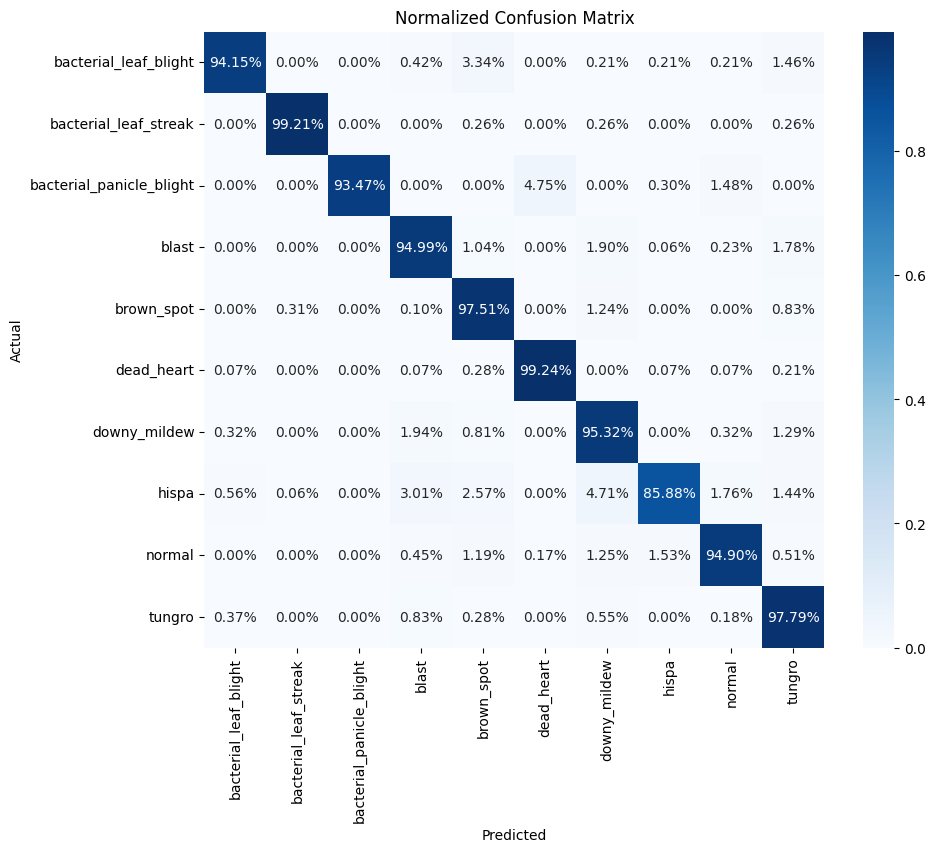

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix')
plt.show()

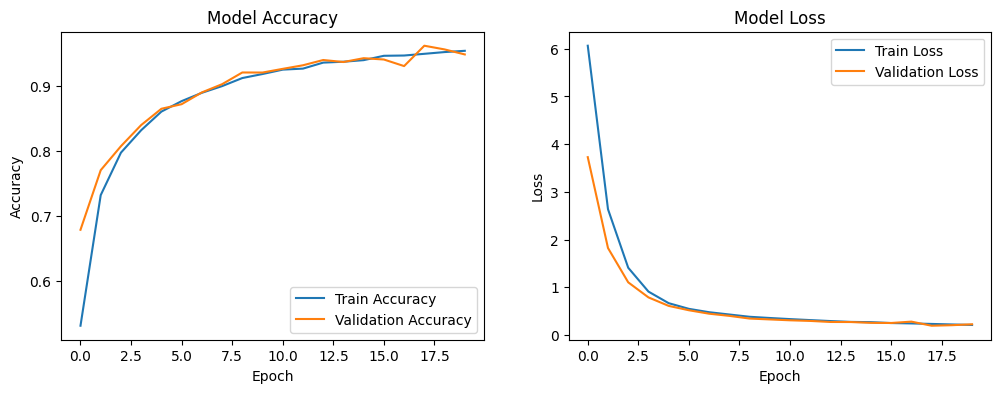

In [ ]:
plt.figure(figsize=(12, 4))

# 🔹 Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 🔹 Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
model.save('/content/drive/MyDrive/efficientnetb0_paddy.h5')


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import os

# Load model
MODEL_PATH = '/content/drive/MyDrive/efficientnetb0_paddy.h5'  # Replace with your model path
model = load_model(MODEL_PATH)

# Classes
class_names = ['bacterial_leaf_blight','bacterial_leaf_streak','bacterial_panicle_blight',
               'blast','brown_spot','dead_heart','downy_mildew','hispa','normal','tungro']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tkinter.filedialog import askopenfilename
img_path = '/content/paddy-disease-classification/train_images/bacterial_leaf_blight/100148.jpg'

In [61]:
def predict_disease(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    return class_names[predicted_class]

In [62]:
def apply_green_mask(img_path, is_normal=False):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if is_normal:
        return None, None, img  # Skip mask generation for healthy leaves

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    # Green mask
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([85, 255, 255])
    green_mask = cv2.inRange(hsv, lower_green, upper_green)

    # Exclusion masks
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([130, 255, 255])
    blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

    lower_dark = np.array([0, 0, 0])
    upper_dark = np.array([180, 50, 50])
    dark_mask = cv2.inRange(hsv, lower_dark, upper_dark)

    exclude_mask = cv2.bitwise_or(blue_mask, dark_mask)
    refined_green_mask = cv2.bitwise_and(green_mask, cv2.bitwise_not(exclude_mask))

    disease_affected_area = cv2.bitwise_and(img, img, mask=refined_green_mask)
    return disease_affected_area, refined_green_mask, img

In [63]:
def estimate_severity(img_path):
    leaf_img, mask, original = apply_green_mask(img_path)

    if leaf_img is None or mask is None:
        return "None", 0, original, None

    hsv_leaf = cv2.cvtColor(leaf_img, cv2.COLOR_RGB2HSV)

    lower_disease = np.array([10, 50, 50])
    upper_disease = np.array([30, 255, 255])

    disease_mask = cv2.inRange(hsv_leaf, lower_disease, upper_disease)
    disease_mask = cv2.bitwise_and(disease_mask, disease_mask, mask=mask)

    disease_area = cv2.countNonZero(disease_mask) * 5
    total_leaf_area = cv2.countNonZero(mask)

    if total_leaf_area == 0:
        return "Unknown", 0, original, None

    severity_percent = round((disease_area / total_leaf_area) * 100, 2)

    if severity_percent < 30:
        severity = "Low"
    elif severity_percent < 60:
        severity = "Medium"
    else:
        severity = "High"

    return severity, severity_percent, original, leaf_img

In [64]:
disease = predict_disease(img_path, model)
print("🟢 Predicted Disease:", disease)

if disease.lower() == 'normal':
    print("✅ The leaf is healthy. No severity estimation required.")
    severity = "None"
    percent = 0
    original, affected = cv2.imread(img_path), None
else:
    print("⚠️ Disease detected. Estimating severity...")
    severity, percent, original, affected = estimate_severity(img_path)

print(f"🔍 Severity: {severity} ({percent}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
🟢 Predicted Disease: bacterial_leaf_blight
⚠️ Disease detected. Estimating severity...
🔍 Severity: Low (29.48%)


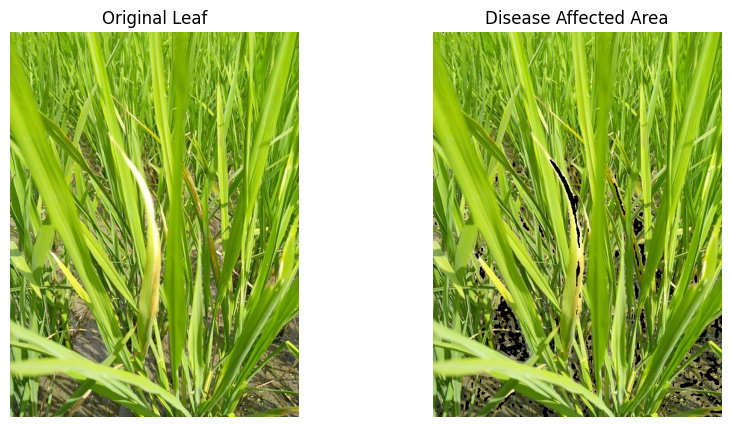

In [65]:
def show_images(original, affected=None):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Leaf")
    plt.axis('off')

    if affected is not None:
        plt.subplot(1, 2, 2)
        plt.imshow(affected)
        plt.title("Disease Affected Area")
        plt.axis('off')

    plt.show()

show_images(original, affected)

In [66]:
print("🧪 Final Result:")
print(f"Disease: {disease}")
print(f"Severity: {severity}")

🧪 Final Result:
Disease: bacterial_leaf_blight
Severity: Low


In [67]:
model.save('/content/drive/MyDrive/paddy_final_model.keras')


In [58]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/paddy_final_model.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 48 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
